# DiagonalOptimiser TinyGPT Benchmark

Self-contained notebook version. It does **not** import `experiments.llm_benchmark`, so it works in Colab/Jupyter even if only this notebook is uploaded.

Research goal: compare AdamW, Lion, Sophia, Muon, and DiagonalOptimiser on convergence behaviour, stability, curvature overhead, and efficiency. Do not interpret this as a claim that DiagonalOptimiser is always faster than AdamW.

In [26]:
from pathlib import Path
from collections import defaultdict
from dataclasses import dataclass, asdict
from statistics import mean, stdev
import csv
import json
import math
import random
import shutil
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display, Markdown
except ImportError:
    def display(x):
        print(x)
    def Markdown(x):
        return x

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.11.0+cpu
CUDA available: False


## Config

Start with `SMOKE = True`. For paper runs, set `SMOKE = False`.

In [27]:
SMOKE = True

CONFIG = {
    "experiment_name": "tinygpt_optimizer_benchmark_smoke" if SMOKE else "tinygpt_optimizer_benchmark",
    "output_dir": "results",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seeds": [0] if SMOKE else [0, 1, 2, 3, 4],
    "model": {
        "vocab_size": 128 if SMOKE else 256,
        "block_size": 32 if SMOKE else 128,
        "n_layer": 1 if SMOKE else 2,
        "n_head": 2 if SMOKE else 4,
        "n_embd": 48 if SMOKE else 128,
        "dropout": 0.0,
    },
    "data": {
        "dataset": "builtin_text",
        "train_tokens": 20_000 if SMOKE else 200_000,
        "val_tokens": 4_000 if SMOKE else 20_000,
        "synthetic_noise": 0.08,
    },
    "train": {
        "batch_size": 4 if SMOKE else 16,
        "base_steps": 5 if SMOKE else 1000,
        "duration_multipliers": [1] if SMOKE else [1, 3, 5, 10],
        "eval_interval": 1 if SMOKE else 100,
        "checkpoint_interval": 5 if SMOKE else 1000,
        "grad_clip": 1.0,
        "target_losses": [4.5, 4.0, 3.5] if SMOKE else [4.0, 3.5, 3.0],
        "wall_clock_checkpoints_sec": [1.0, 5.0, 10.0] if SMOKE else [30.0, 60.0, 120.0],
    },
    "optimizers": {
        "names": ["AdamW", "Lion", "Sophia", "Muon", "DiagonalOptimiser"],
        "learning_rates": {
            "AdamW": 3e-4,
            "Lion": 1e-4,
            "Sophia": 3e-4,
            "Muon": 2e-4,
            "DiagonalOptimiser": 3e-4,
        },
        "weight_decay": 0.01,
    },
}

CLEAN_OUTPUT_DIR = True
GENERATE_PLOTS = True
MAX_RUNS_FOR_NOTEBOOK = None

device = torch.device(CONFIG["device"])
output_root = Path(CONFIG["output_dir"]) / CONFIG["experiment_name"]
plot_dir = Path(CONFIG["output_dir"]) / "plots" / CONFIG["experiment_name"]

if CLEAN_OUTPUT_DIR and output_root.exists():
    shutil.rmtree(output_root)
if CLEAN_OUTPUT_DIR and plot_dir.exists():
    shutil.rmtree(plot_dir)
output_root.mkdir(parents=True, exist_ok=True)
(output_root / "config.resolved.json").write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

print(json.dumps(CONFIG, indent=2))

{
  "experiment_name": "tinygpt_optimizer_benchmark_smoke",
  "output_dir": "results",
  "device": "cpu",
  "seeds": [
    0
  ],
  "model": {
    "vocab_size": 128,
    "block_size": 32,
    "n_layer": 1,
    "n_head": 2,
    "n_embd": 48,
    "dropout": 0.0
  },
  "data": {
    "dataset": "synthetic",
    "train_tokens": 20000,
    "val_tokens": 4000,
    "synthetic_noise": 0.08
  },
  "train": {
    "batch_size": 4,
    "base_steps": 2,
    "duration_multipliers": [
      1
    ],
    "eval_interval": 1,
    "checkpoint_interval": 2,
    "grad_clip": 1.0,
    "target_losses": [
      4.8,
      4.6,
      4.4
    ],
    "wall_clock_checkpoints_sec": [
      1.0,
      5.0,
      10.0
    ]
  },
  "optimizers": {
    "names": [
      "AdamW",
      "Lion",
      "Sophia",
      "Muon",
      "DiagonalOptimiser"
    ],
    "learning_rates": {
      "AdamW": 0.0003,
      "Lion": 0.0001,
      "Sophia": 0.0003,
      "Muon": 0.0002,
      "DiagonalOptimiser": 0.0003
    },
    "weight_

## Data

In [28]:
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


BUILTIN_TINY_TEXT = """
In a quiet laboratory, a small model learned to predict the next token.
The experiment was repeated with different random seeds so the results would
not depend on a lucky initialization. Curvature can help when the landscape is
ill conditioned, but every optimizer must pay for the computation it performs.

The researcher measured validation loss, gradient norm, memory, throughput, and
wall clock time. A fair benchmark reports both convergence and cost. It also
shows failure cases, because scientific claims should survive difficult tests.

Tiny stories are useful for debugging language models. A robot sorted colored
blocks, then wrote careful notes about each step. The notes were simple, but
the repeated structure let the model learn patterns beyond random guessing.
"""


def encode_bytes(text, vocab_size):
    return torch.tensor([b % vocab_size for b in text.encode("utf-8", errors="ignore")], dtype=torch.long)


def builtin_text_tokens(seed, train_tokens, val_tokens, vocab_size):
    needed = train_tokens + val_tokens
    repeats = max(needed // len(BUILTIN_TINY_TEXT) + 2, 4)
    tokens = encode_bytes((BUILTIN_TINY_TEXT.strip() + "\n") * repeats, vocab_size)
    g = torch.Generator().manual_seed(seed)
    offset = int(torch.randint(0, max(len(tokens) - 1, 1), (1,), generator=g))
    tokens = torch.cat([tokens[offset:], tokens[:offset]])
    return tokens[:train_tokens].clone(), tokens[train_tokens:train_tokens + val_tokens].clone()


def synthetic_tokens(seed, length, vocab_size, noise):
    g = torch.Generator().manual_seed(seed)
    motif_count, motif_length = 32, 24
    motifs = torch.randint(0, vocab_size, (motif_count, motif_length), generator=g)
    choices = torch.randint(0, motif_count, (length // motif_length + 1,), generator=g)
    stream = motifs[choices].flatten()[:length].clone()
    mask = torch.rand(length, generator=g) < noise
    stream[mask] = torch.randint(0, vocab_size, (int(mask.sum()),), generator=g)
    return stream.long()


def load_data(seed):
    cfg = CONFIG["data"]
    vocab_size = CONFIG["model"]["vocab_size"]
    if cfg["dataset"] in {"builtin_text", "tiny_text", "text"}:
        return builtin_text_tokens(seed, cfg["train_tokens"], cfg["val_tokens"], vocab_size)
    train = synthetic_tokens(seed, cfg["train_tokens"], vocab_size, cfg["synthetic_noise"])
    val = synthetic_tokens(seed + 10_000, cfg["val_tokens"], vocab_size, cfg["synthetic_noise"])
    return train, val


def get_batch(data, batch_size, block_size, step, device):
    max_start = len(data) - block_size - 1
    start = (step * batch_size * block_size) % max_start
    offsets = (start + torch.arange(batch_size) * block_size) % max_start
    x = torch.stack([data[int(i):int(i) + block_size] for i in offsets])
    y = torch.stack([data[int(i) + 1:int(i) + block_size + 1] for i in offsets])
    return x.to(device), y.to(device)

## TinyGPT Model

In [29]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size))

    def forward(self, x):
        b, t, c = x.shape
        q, k, v = self.qkv(x).split(c, dim=2)
        q = q.view(b, t, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(b, t, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(b, t, self.n_head, self.head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :t, :t] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        y = self.attn_dropout(att) @ v
        y = y.transpose(1, 2).contiguous().view(b, t, c)
        return self.resid_dropout(self.proj(y))


class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(nn.Linear(n_embd, 4 * n_embd), nn.GELU(), nn.Linear(4 * n_embd, n_embd), nn.Dropout(dropout))

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class TinyGPT(nn.Module):
    def __init__(self, vocab_size, block_size, n_layer, n_head, n_embd, dropout):
        super().__init__()
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        _, t = idx.shape
        pos = torch.arange(t, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(pos)[None, :, :]
        x = self.blocks(self.drop(x))
        logits = self.lm_head(self.ln_f(x))
        loss = None if targets is None else F.cross_entropy(logits.view(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

## Optimizers

In [30]:
class Lion(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99), weight_decay=0.0):
        super().__init__(params, dict(lr=lr, betas=betas, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr, wd = group["lr"], group["weight_decay"]
            beta1, beta2 = group["betas"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                if wd:
                    p.mul_(1 - lr * wd)
                state = self.state[p]
                if not state:
                    state["exp_avg"] = torch.zeros_like(p)
                m = state["exp_avg"]
                update = m.mul(beta1).add(p.grad, alpha=1 - beta1)
                p.add_(update.sign(), alpha=-lr)
                m.mul_(beta2).add_(p.grad, alpha=1 - beta2)


class SophiaG(torch.optim.Optimizer):
    def __init__(self, params, lr=3e-4, betas=(0.965, 0.99), rho=0.04, eps=1e-12, weight_decay=0.0, update_interval=10):
        super().__init__(params, dict(lr=lr, betas=betas, rho=rho, eps=eps, weight_decay=weight_decay, update_interval=update_interval))

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr, rho, eps, wd = group["lr"], group["rho"], group["eps"], group["weight_decay"]
            beta1, beta2 = group["betas"]
            interval = group["update_interval"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if not state:
                    state["step"] = 0
                    state["exp_avg"] = torch.zeros_like(p)
                    state["hessian"] = torch.zeros_like(p)
                state["step"] += 1
                m, h = state["exp_avg"], state["hessian"]
                m.mul_(beta1).add_(p.grad, alpha=1 - beta1)
                if state["step"] % interval == 1:
                    h.mul_(beta2).addcmul_(p.grad, p.grad, value=1 - beta2)
                if wd:
                    p.mul_(1 - lr * wd)
                p.add_((m / (rho * h.add(eps))).clamp_(-1, 1), alpha=-lr)


class MuonFallback(torch.optim.Optimizer):
    def __init__(self, params, lr=2e-4, momentum=0.95, ns_steps=5, weight_decay=0.0):
        super().__init__(params, dict(lr=lr, momentum=momentum, ns_steps=ns_steps, weight_decay=weight_decay))

    @staticmethod
    def zeropower(g, steps=5, eps=1e-7):
        if g.ndim < 2:
            return g.sign()
        x = g.float()
        transposed = x.size(0) > x.size(1)
        if transposed:
            x = x.T
        x = x / (x.norm() + eps)
        a, b, c = 3.4445, -4.7750, 2.0315
        for _ in range(steps):
            xx = x @ x.T
            x = a * x + (b * xx + c * xx @ xx) @ x
        return (x.T if transposed else x).to(g.dtype)

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr, mom, wd, ns = group["lr"], group["momentum"], group["weight_decay"], group["ns_steps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                if wd:
                    p.mul_(1 - lr * wd)
                state = self.state[p]
                if not state:
                    state["momentum_buffer"] = torch.zeros_like(p)
                buf = state["momentum_buffer"]
                buf.mul_(mom).add_(p.grad)
                update = self.zeropower(buf, ns) if p.ndim >= 2 else buf.sign()
                p.add_(update, alpha=-lr)


class DiagonalOptimiser(torch.optim.Optimizer):
    def __init__(self, params, lr=3e-4, beta=0.99, eps=1e-8, weight_decay=0.0, max_update=1.0, curvature_interval=10, fd_eps=1e-3):
        super().__init__(params, dict(lr=lr, beta=beta, eps=eps, weight_decay=weight_decay, max_update=max_update, curvature_interval=curvature_interval, fd_eps=fd_eps))
        self.curvature_updates = 0
        self.hvp_probes = 0

    @torch.no_grad()
    def _ema_grad_curvature(self, group):
        for p in group["params"]:
            if p.grad is None:
                continue
            state = self.state[p]
            if not state:
                state["step"] = 0
                state["diag_curvature"] = torch.zeros_like(p)
            state["diag_curvature"].mul_(group["beta"]).addcmul_(p.grad, p.grad, value=1 - group["beta"])

    def _fd_refresh(self, group, closure):
        if closure is None:
            self._ema_grad_curvature(group)
            self.curvature_updates += 1
            return
        fd_eps = group["fd_eps"]
        with torch.no_grad():
            params = [p for p in group["params"] if p.grad is not None]
            base_grads = [p.grad.detach().clone() for p in params]
            directions = [torch.sign(g) for g in base_grads]
            for p, d in zip(params, directions):
                p.add_(d, alpha=fd_eps)
        closure()
        with torch.no_grad():
            for p, base_grad in zip(params, base_grads):
                hvp_diag = (p.grad - base_grad).abs() / fd_eps
                state = self.state[p]
                if not state:
                    state["step"] = 0
                    state["diag_curvature"] = torch.zeros_like(p)
                state["diag_curvature"].mul_(group["beta"]).add_(hvp_diag, alpha=1 - group["beta"])
            for p, d, base_grad in zip(params, directions, base_grads):
                p.add_(d, alpha=-fd_eps)
                p.grad.copy_(base_grad)
        self.curvature_updates += 1
        self.hvp_probes += 1

    def step(self, closure=None):
        for group in self.param_groups:
            first = next((p for p in group["params"] if p.grad is not None), None)
            if first is None:
                continue
            first_state = self.state[first]
            group_step = first_state.get("step", 0) + 1 if first_state else 1
            if group_step == 1 or group_step % group["curvature_interval"] == 0:
                self._fd_refresh(group, closure)
            else:
                self._ema_grad_curvature(group)
                self.curvature_updates += 1
            with torch.no_grad():
                for p in group["params"]:
                    if p.grad is None:
                        continue
                    state = self.state[p]
                    state["step"] = group_step
                    if group["weight_decay"]:
                        p.mul_(1 - group["lr"] * group["weight_decay"])
                    update = p.grad / (state["diag_curvature"].sqrt() + group["eps"])
                    p.add_(update.clamp(-group["max_update"], group["max_update"]), alpha=-group["lr"])


def make_optimizer(name, model):
    lr = CONFIG["optimizers"]["learning_rates"][name]
    wd = CONFIG["optimizers"]["weight_decay"]
    if name == "AdamW":
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    if name == "Lion":
        return Lion(model.parameters(), lr=lr, weight_decay=wd)
    if name == "Sophia":
        return SophiaG(model.parameters(), lr=lr, weight_decay=wd)
    if name == "Muon":
        return MuonFallback(model.parameters(), lr=lr, weight_decay=wd)
    if name == "DiagonalOptimiser":
        return DiagonalOptimiser(model.parameters(), lr=lr, weight_decay=wd)
    raise ValueError(name)

## Training, Metrics, and Analysis

In [31]:
@torch.no_grad()
def evaluate(model, val_data, eval_batches=8):
    model.eval()
    losses = []
    tr = CONFIG["train"]
    for i in range(eval_batches):
        x, y = get_batch(val_data, tr["batch_size"], CONFIG["model"]["block_size"], i, device)
        _, loss = model(x, y)
        losses.append(float(loss.detach().cpu()))
    model.train()
    return sum(losses) / len(losses)


def grad_norm(parameters):
    total = 0.0
    for p in parameters:
        if p.grad is not None:
            n = p.grad.detach().data.norm(2).item()
            total += n * n
    return math.sqrt(total)


def write_csv(path, rows):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    if not rows:
        return
    with Path(path).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


def write_json(path, data):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    Path(path).write_text(json.dumps(data, indent=2), encoding="utf-8")


def steps_to_targets(rows):
    out = {}
    for target in CONFIG["train"]["target_losses"]:
        hit = next((r for r in rows if r["val_loss"] <= target), None)
        out[f"steps_to_loss_{target}"] = hit["step"] if hit else None
    return out


def loss_at_wall_times(rows):
    out = {}
    for t in CONFIG["train"]["wall_clock_checkpoints_sec"]:
        candidates = [r for r in rows if r["wall_time_sec"] <= t]
        out[f"loss_at_{t:g}s"] = candidates[-1]["val_loss"] if candidates else None
    return out



def area_under_curve(rows, x_key, y_key):
    ordered = sorted(rows, key=lambda r: float(r[x_key]))
    if len(ordered) < 2:
        return 0.0
    area = 0.0
    for left, right in zip(ordered[:-1], ordered[1:]):
        dx = max(float(right[x_key]) - float(left[x_key]), 0.0)
        area += 0.5 * (float(left[y_key]) + float(right[y_key])) * dx
    return area

def summarize_run(rows):
    last = max(rows, key=lambda r: r["step"])
    best = min(rows, key=lambda r: r["val_loss"])
    summary = {
        "optimizer": last["optimizer"],
        "seed": last["seed"],
        "duration_multiplier": last["duration_multiplier"],
        "final_train_loss": last["train_loss"],
        "final_val_loss": last["val_loss"],
        "best_val_loss": best["val_loss"],
        "best_step": best["step"],
        "wall_time_sec": last["wall_time_sec"],
        "tokens_per_sec": last["tokens_per_sec"],
        "peak_memory_mb": last["peak_memory_mb"],
        "last_grad_norm": last["grad_norm"],
        "last_lr": last["learning_rate"],
        "val_loss_auc_steps": area_under_curve(rows, "step", "val_loss"),
        "val_loss_auc_time": area_under_curve(rows, "wall_time_sec", "val_loss"),
        "stable": last["stable"],
        "curvature_updates": last["curvature_updates"],
        "hvp_probes": last["hvp_probes"],
    }
    summary.update(steps_to_targets(rows))
    summary.update(loss_at_wall_times(rows))
    return summary


def aggregate_summaries(summaries):
    grouped = defaultdict(list)
    for r in summaries:
        grouped[(r["optimizer"], r["duration_multiplier"])].append(r)
    keys = ["final_val_loss", "best_val_loss", "wall_time_sec", "tokens_per_sec", "peak_memory_mb", "last_grad_norm", "last_lr", "val_loss_auc_steps", "val_loss_auc_time", "curvature_updates", "hvp_probes"]
    keys += [k for k in summaries[0] if k.startswith("steps_to_loss_") or k.startswith("loss_at_")] if summaries else []
    out = []
    for (opt, dur), rows in sorted(grouped.items()):
        agg = {"optimizer": opt, "duration_multiplier": dur, "runs": len(rows), "stable_runs": sum(bool(r["stable"]) for r in rows)}
        for k in keys:
            vals = [r[k] for r in rows if r.get(k) is not None]
            vals = [float(v) for v in vals]
            agg[f"{k}_mean"] = mean(vals) if vals else None
            agg[f"{k}_std"] = stdev(vals) if len(vals) > 1 else (0.0 if vals else None)
        out.append(agg)
    return out


def md_table(aggregate):
    target = f"steps_to_loss_{CONFIG['train']['target_losses'][1]}"
    lines = [
        "| Optimizer | Duration | Final Loss | Best Loss | Steps to Target | Time | Tokens/sec | Stability |",
        "|---|---:|---:|---:|---:|---:|---:|---:|",
    ]
    for r in aggregate:
        def pm(k, p=3):
            avg, sd = r.get(f"{k}_mean"), r.get(f"{k}_std")
            return "n/a" if avg is None else f"{avg:.{p}f} +/- {sd:.{p}f}"
        lines.append(f"| {r['optimizer']} | {r['duration_multiplier']}x | {pm('final_val_loss')} | {pm('best_val_loss')} | {pm(target, 1)} | {pm('wall_time_sec', 2)} | {pm('tokens_per_sec', 0)} | {r['stable_runs']}/{r['runs']} |")
    return "\n".join(lines)

## Run Benchmark

In [32]:
def train_one(optimizer_name, seed, duration_multiplier, run_dir):
    set_seed(seed)
    train_data, val_data = load_data(seed)
    model = TinyGPT(**CONFIG["model"]).to(device)
    optimizer = make_optimizer(optimizer_name, model)
    tr = CONFIG["train"]
    max_steps = tr["base_steps"] * duration_multiplier

    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    rows, stable, total_tokens = [], True, 0
    start = time.perf_counter()

    for step in range(1, max_steps + 1):
        step_start = time.perf_counter()
        x, y = get_batch(train_data, tr["batch_size"], CONFIG["model"]["block_size"], step, device)

        def closure():
            optimizer.zero_grad(set_to_none=True)
            _, closure_loss = model(x, y)
            closure_loss.backward()
            if tr["grad_clip"] > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), tr["grad_clip"])
            return closure_loss

        optimizer.zero_grad(set_to_none=True)
        _, loss = model(x, y)
        loss.backward()
        gnorm = grad_norm(model.parameters())
        if tr["grad_clip"] > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), tr["grad_clip"])

        if optimizer_name == "DiagonalOptimiser":
            optimizer.step(closure=closure)
        else:
            optimizer.step()

        if device.type == "cuda":
            torch.cuda.synchronize()

        total_tokens += x.numel()
        train_loss = float(loss.detach().cpu())
        stable = stable and math.isfinite(train_loss) and math.isfinite(gnorm)

        if step == 1 or step % tr["eval_interval"] == 0 or step == max_steps or not stable:
            elapsed = time.perf_counter() - start
            rows.append({
                "optimizer": optimizer_name,
                "seed": seed,
                "duration_multiplier": duration_multiplier,
                "step": step,
                "train_loss": train_loss,
                "val_loss": evaluate(model, val_data),
                "wall_time_sec": elapsed,
                "step_time_sec": time.perf_counter() - step_start,
                "tokens_per_sec": total_tokens / max(elapsed, 1e-9),
                "peak_memory_mb": torch.cuda.max_memory_allocated() / 1024**2 if device.type == "cuda" else 0.0,
                "grad_norm": gnorm,
                "learning_rate": float(optimizer.param_groups[0]["lr"]),
                "stable": stable,
                "curvature_updates": float(getattr(optimizer, "curvature_updates", 0)),
                "hvp_probes": float(getattr(optimizer, "hvp_probes", 0)),
            })

        if step % tr["checkpoint_interval"] == 0 or step == max_steps or not stable:
            ckpt = run_dir / "checkpoints" / f"step_{step}.pt"
            ckpt.parent.mkdir(parents=True, exist_ok=True)
            torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(), "step": step}, ckpt)
        if not stable:
            break

    return rows, summarize_run(rows)


all_metrics, summaries = [], []
run_count = 0

for dur in CONFIG["train"]["duration_multipliers"]:
    for opt_name in CONFIG["optimizers"]["names"]:
        for seed in CONFIG["seeds"]:
            if MAX_RUNS_FOR_NOTEBOOK is not None and run_count >= MAX_RUNS_FOR_NOTEBOOK:
                break
            run_count += 1
            run_dir = output_root / "runs" / f"{opt_name}_seed{seed}_{dur}x"
            print(f"[{run_count}] {opt_name} seed={seed} duration={dur}x")
            rows, summary = train_one(opt_name, seed, dur, run_dir)
            write_csv(run_dir / "metrics.csv", rows)
            write_json(run_dir / "summary.json", summary)
            all_metrics.extend(rows)
            summaries.append(summary)
        if MAX_RUNS_FOR_NOTEBOOK is not None and run_count >= MAX_RUNS_FOR_NOTEBOOK:
            break
    if MAX_RUNS_FOR_NOTEBOOK is not None and run_count >= MAX_RUNS_FOR_NOTEBOOK:
        break

aggregate = aggregate_summaries(summaries)
write_csv(output_root / "metrics.csv", all_metrics)
write_csv(output_root / "summaries.csv", summaries)
write_csv(output_root / "aggregate.csv", aggregate)
write_json(output_root / "aggregate.json", aggregate)
table = md_table(aggregate)
(output_root / "results_table.md").write_text(table + "\n", encoding="utf-8")
print(table)

[1] AdamW seed=0 duration=1x
[2] Lion seed=0 duration=1x
[3] Sophia seed=0 duration=1x
[4] Muon seed=0 duration=1x
[5] DiagonalOptimiser seed=0 duration=1x
| Optimizer | Duration | Final Loss | Best Loss | Steps to Target | Time | Tokens/sec | Stability |
|---|---:|---:|---:|---:|---:|---:|---:|
| AdamW | 1x | 4.864 +/- 0.000 | 4.864 +/- 0.000 | n/a | 0.03 +/- 0.00 | 7738 +/- 0 | 1/1 |
| DiagonalOptimiser | 1x | 4.865 +/- 0.000 | 4.865 +/- 0.000 | n/a | 0.03 +/- 0.00 | 9775 +/- 0 | 1/1 |
| Lion | 1x | 4.865 +/- 0.000 | 4.865 +/- 0.000 | n/a | 0.02 +/- 0.00 | 12472 +/- 0 | 1/1 |
| Muon | 1x | 4.865 +/- 0.000 | 4.865 +/- 0.000 | n/a | 0.02 +/- 0.00 | 10504 +/- 0 | 1/1 |
| Sophia | 1x | 4.864 +/- 0.000 | 4.864 +/- 0.000 | n/a | 0.02 +/- 0.00 | 13276 +/- 0 | 1/1 |


## Tables

In [40]:
if pd is not None:
    metrics_df = pd.read_csv(output_root / "metrics.csv")
    summaries_df = pd.read_csv(output_root / "summaries.csv")
    aggregate_df = pd.read_csv(output_root / "aggregate.csv")
    display(aggregate_df)
else:
    print((output_root / "results_table.md").read_text(encoding="utf-8"))

,optimizer,duration_multiplier,runs,stable_runs,final_val_loss_mean,final_val_loss_std,best_val_loss_mean,best_val_loss_std,wall_time_sec_mean,wall_time_sec_std,...,steps_to_loss_4.6_mean,steps_to_loss_4.6_std,steps_to_loss_4.4_mean,steps_to_loss_4.4_std,loss_at_1s_mean,loss_at_1s_std,loss_at_5s_mean,loss_at_5s_std,loss_at_10s_mean,loss_at_10s_std
0,AdamW,1,1,1,4.864392,0.0,4.864392,0.0,0.033083,0.0,...,NaN,NaN,NaN,NaN,4.864392,0.0,4.864392,0.0,4.864392,0.0
1,DiagonalOptimiser,1,1,1,4.865085,0.0,4.865085,0.0,0.026190,0.0,...,NaN,NaN,NaN,NaN,4.865085,0.0,4.865085,0.0,4.865085,0.0
2,Lion,1,1,1,4.864932,0.0,4.864932,0.0,0.020525,0.0,...,NaN,NaN,NaN,NaN,4.864932,0.0,4.864932,0.0,4.864932,0.0
3,Muon,1,1,1,4.864861,0.0,4.864861,0.0,0.024372,0.0,...,NaN,NaN,NaN,NaN,4.864861,0.0,4.864861,0.0,4.864861,0.0
4,Sophia,1,1,1,4.864342,0.0,4.864342,0.0,0.019283,0.0,...,NaN,NaN,NaN,NaN,4.864342,0.0,4.864342,0.0,4.864342,0.0


## Publication Table

This table is the paper-facing summary: mean +/- standard deviation across seeds for final loss, best loss, target-loss steps, wall-clock time, throughput, and stability.

In [48]:
result_table_text = (output_root / "results_table.md").read_text(encoding="utf-8")
display(Markdown(result_table_text))

NameError: name 'Markdown' is not defined

## Core Metric Values

These are the numeric values behind the publication table. Use this for copying exact numbers into analysis notes.

In [49]:
if pd is not None:
    core_columns = [
        "optimizer",
        "duration_multiplier",
        "runs",
        "stable_runs",
        "final_val_loss_mean",
        "final_val_loss_std",
        "best_val_loss_mean",
        "best_val_loss_std",
        "val_loss_auc_steps_mean",
        "val_loss_auc_steps_std",
        "val_loss_auc_time_mean",
        "val_loss_auc_time_std",
    ]
    core_columns = [c for c in core_columns if c in aggregate_df.columns]
    display(aggregate_df[core_columns].sort_values(["duration_multiplier", "optimizer"]))
else:
    for row in aggregate:
        print(row)

,optimizer,duration_multiplier,runs,stable_runs,final_val_loss_mean,final_val_loss_std,best_val_loss_mean,best_val_loss_std
0,AdamW,1,1,1,4.864392,0.0,4.864392,0.0
1,DiagonalOptimiser,1,1,1,4.865085,0.0,4.865085,0.0
2,Lion,1,1,1,4.864932,0.0,4.864932,0.0
3,Muon,1,1,1,4.864861,0.0,4.864861,0.0
4,Sophia,1,1,1,4.864342,0.0,4.864342,0.0


## Convergence Targets

Steps required to reach each configured validation-loss threshold. Blank/NaN means the optimizer did not reach that target in the allotted budget.

In [50]:
if pd is not None:
    target_cols = [c for c in aggregate_df.columns if c.startswith("steps_to_loss_")]
    target_cols = [c for c in target_cols if c.endswith("_mean") or c.endswith("_std")]
    display(aggregate_df[["optimizer", "duration_multiplier"] + target_cols].sort_values(["duration_multiplier", "optimizer"]))
else:
    for row in aggregate:
        print({k: v for k, v in row.items() if k.startswith("steps_to_loss_") or k in {"optimizer", "duration_multiplier"}})

,optimizer,duration_multiplier,steps_to_loss_4.8_mean,steps_to_loss_4.8_std,steps_to_loss_4.6_mean,steps_to_loss_4.6_std,steps_to_loss_4.4_mean,steps_to_loss_4.4_std
0,AdamW,1,NaN,NaN,NaN,NaN,NaN,NaN
1,DiagonalOptimiser,1,NaN,NaN,NaN,NaN,NaN,NaN
2,Lion,1,NaN,NaN,NaN,NaN,NaN,NaN
3,Muon,1,NaN,NaN,NaN,NaN,NaN,NaN
4,Sophia,1,NaN,NaN,NaN,NaN,NaN,NaN


## Timing, Throughput, and Memory

These values are important for fair interpretation. Timing includes forward pass, backward pass, gradient clipping, and `optimizer.step()`. For DiagonalOptimiser, curvature refresh/HVP probe overhead is included.

In [51]:
if pd is not None:
    perf_cols = [
        "optimizer",
        "duration_multiplier",
        "wall_time_sec_mean",
        "wall_time_sec_std",
        "tokens_per_sec_mean",
        "tokens_per_sec_std",
        "peak_memory_mb_mean",
        "peak_memory_mb_std",
        "last_grad_norm_mean",
        "last_grad_norm_std",
        "last_lr_mean",
    ]
    perf_cols = [c for c in perf_cols if c in aggregate_df.columns]
    display(aggregate_df[perf_cols].sort_values(["duration_multiplier", "optimizer"]))
else:
    for row in aggregate:
        print({k: row.get(k) for k in row if k in {"optimizer", "duration_multiplier"} or "time" in k or "tokens" in k or "memory" in k or "grad" in k or "lr" in k})

,optimizer,duration_multiplier,wall_time_sec_mean,wall_time_sec_std,tokens_per_sec_mean,tokens_per_sec_std,peak_memory_mb_mean,peak_memory_mb_std,last_grad_norm_mean,last_grad_norm_std
0,AdamW,1,0.033083,0.0,7738.056627,0.0,0.0,0.0,1.285763,0.0
1,DiagonalOptimiser,1,0.026190,0.0,9774.692946,0.0,0.0,0.0,1.285621,0.0
2,Lion,1,0.020525,0.0,12472.300288,0.0,0.0,0.0,1.285642,0.0
3,Muon,1,0.024372,0.0,10503.759915,0.0,0.0,0.0,1.285825,0.0
4,Sophia,1,0.019283,0.0,13275.774553,0.0,0.0,0.0,1.285764,0.0


## Per-Run Values

Per-seed summaries before aggregation. For the full benchmark this should contain at least 5 seeds per optimizer.

In [52]:
if pd is not None:
    per_run_cols = [
        "optimizer",
        "seed",
        "duration_multiplier",
        "final_train_loss",
        "final_val_loss",
        "best_val_loss",
        "best_step",
        "wall_time_sec",
        "tokens_per_sec",
        "peak_memory_mb",
        "last_grad_norm",
        "last_lr",
        "val_loss_auc_steps",
        "stable",
    ]
    per_run_cols = [c for c in per_run_cols if c in summaries_df.columns]
    display(summaries_df[per_run_cols].sort_values(["duration_multiplier", "optimizer", "seed"]))
else:
    for row in summaries:
        print(row)

,optimizer,seed,duration_multiplier,final_train_loss,final_val_loss,best_val_loss,best_step,wall_time_sec,tokens_per_sec,peak_memory_mb,last_grad_norm,stable
0,AdamW,0,1,4.866976,4.864392,4.864392,2,0.033083,7738.056627,0.0,1.285763,True
4,DiagonalOptimiser,0,1,4.869377,4.865085,4.865085,2,0.026190,9774.692946,0.0,1.285621,True
1,Lion,0,1,4.868725,4.864932,4.864932,2,0.020525,12472.300288,0.0,1.285642,True
3,Muon,0,1,4.869392,4.864861,4.864861,2,0.024372,10503.759915,0.0,1.285825,True
2,Sophia,0,1,4.866975,4.864342,4.864342,2,0.019283,13275.774553,0.0,1.285764,True


## Loss Movement Check

This checks whether the model actually learned during the run by comparing the first logged validation loss with the final and best validation loss.

In [53]:
if pd is not None:
    movement_rows = []
    for (optimizer, seed, duration), group in metrics_df.groupby(["optimizer", "seed", "duration_multiplier"]):
        group = group.sort_values("step")
        first_val = float(group.iloc[0]["val_loss"])
        final_val = float(group.iloc[-1]["val_loss"])
        best_val = float(group["val_loss"].min())
        movement_rows.append({
            "optimizer": optimizer,
            "seed": seed,
            "duration_multiplier": duration,
            "first_val_loss": first_val,
            "final_val_loss": final_val,
            "best_val_loss": best_val,
            "final_improvement": first_val - final_val,
            "best_improvement": first_val - best_val,
        })
    movement_df = pd.DataFrame(movement_rows)
    display(movement_df.sort_values(["duration_multiplier", "optimizer", "seed"]))
else:
    for row in all_metrics:
        pass
    print("Install pandas to display the loss movement table.")

,optimizer,seed,duration_multiplier,first_val_loss,final_val_loss,best_val_loss,final_improvement,best_improvement
0,AdamW,0,1,4.864845,4.864392,4.864392,0.000453,0.000453
1,DiagonalOptimiser,0,1,4.865172,4.865085,4.865085,0.000087,0.000087
2,Lion,0,1,4.865088,4.864932,4.864932,0.000156,0.000156
3,Muon,0,1,4.865048,4.864861,4.864861,0.000187,0.000187
4,Sophia,0,1,4.864845,4.864342,4.864342,0.000503,0.000503


## DiagonalOptimiser Cost Values

Curvature updates and finite-difference HVP probes are reported explicitly so DiagonalOptimiser cannot look faster by hiding curvature work.

In [54]:
if pd is not None:
    cost_cols = [
        "optimizer",
        "duration_multiplier",
        "curvature_updates_mean",
        "curvature_updates_std",
        "hvp_probes_mean",
        "hvp_probes_std",
        "wall_time_sec_mean",
        "tokens_per_sec_mean",
    ]
    cost_cols = [c for c in cost_cols if c in aggregate_df.columns]
    display(aggregate_df[aggregate_df["optimizer"] == "DiagonalOptimiser"][cost_cols])
else:
    for row in aggregate:
        if row.get("optimizer") == "DiagonalOptimiser":
            print(row)

,optimizer,duration_multiplier,curvature_updates_mean,curvature_updates_std,hvp_probes_mean,hvp_probes_std,wall_time_sec_mean,tokens_per_sec_mean
1,DiagonalOptimiser,1,2.0,0.0,1.0,0.0,0.02619,9774.692946


## Difficult Optimization Results

If you ran `experiments/difficult_optimization.py`, this cell loads those tables too. These tests are more aligned with DiagonalOptimiser's curvature-aware research story than the small Transformer alone.

In [58]:
difficult_candidates = [
    Path("results/difficult_optimization/aggregate.csv"),
    Path("results/difficult_optimization_smoke/aggregate.csv"),
]
difficult_path = next((p for p in difficult_candidates if p.exists()), None)
if difficult_path is None:
    print("No difficult optimization aggregate found yet.")
    print("Run: python experiments/difficult_optimization.py --max-iter 500 --seeds 0,1,2,3,4")
elif pd is not None:
    difficult_df = pd.read_csv(difficult_path)
    print(f"Loaded {difficult_path}")
    display(difficult_df)
else:
    print(difficult_path.read_text(encoding="utf-8")[:4000])

No difficult optimization aggregate found yet.
Run: python experiments/difficult_optimization.py --max-iter 500 --seeds 0,1,2,3,4


## DiagonalOptimiser Curvature Check

In [56]:
if pd is not None:
    diag = metrics_df[metrics_df["optimizer"] == "DiagonalOptimiser"]
    display(diag[["seed", "duration_multiplier", "step", "curvature_updates", "hvp_probes", "wall_time_sec", "tokens_per_sec", "grad_norm", "stable"]].tail(20))
    print("max curvature updates:", diag["curvature_updates"].max())
    print("max HVP probes:", diag["hvp_probes"].max())
else:
    for row in all_metrics:
        if row["optimizer"] == "DiagonalOptimiser":
            print(row)

,seed,duration_multiplier,step,curvature_updates,hvp_probes,wall_time_sec,tokens_per_sec,grad_norm,stable
8,0,1,1,1.0,1.0,0.010009,12788.197773,1.174587,True
9,0,1,2,2.0,1.0,0.026190,9774.692946,1.285621,True


max curvature updates: 2.0
max HVP probes: 1.0


## Plots

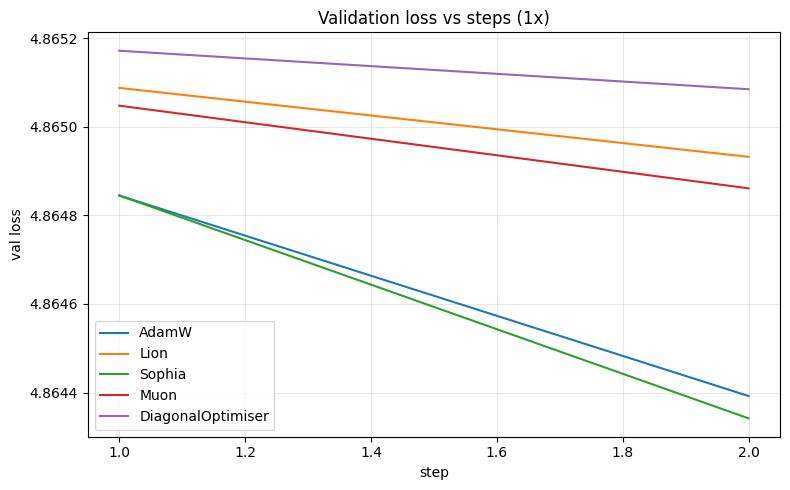

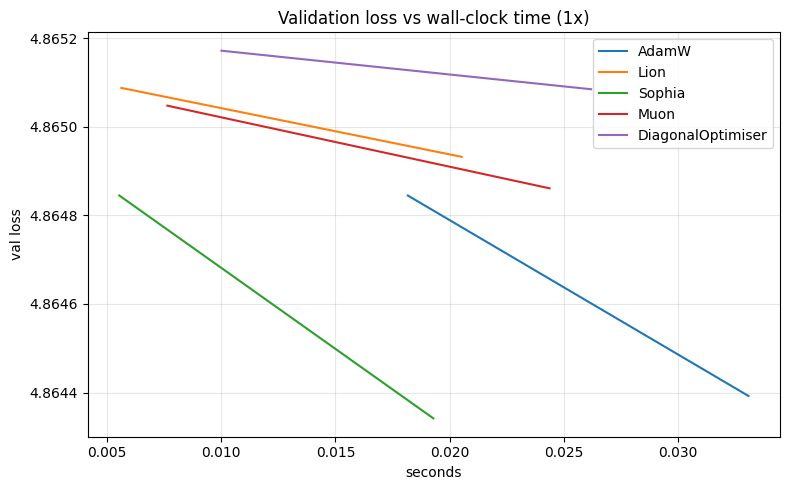

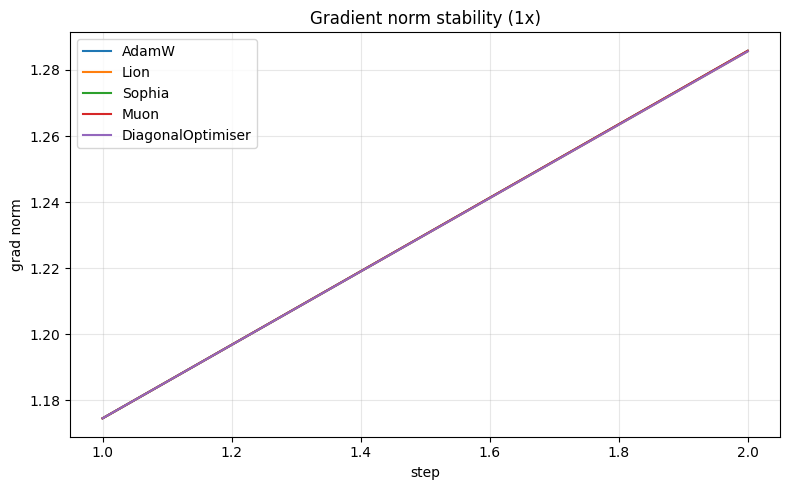

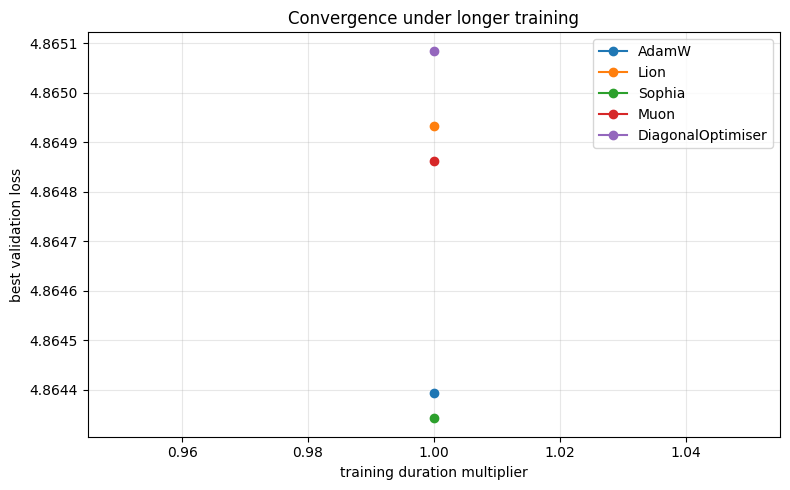

In [57]:
def mean_curve(rows, x_key, y_key):
    by_x = defaultdict(list)
    for r in rows:
        by_x[float(r[x_key])].append(float(r[y_key]))
    xs = sorted(by_x)
    ys = [mean(by_x[x]) for x in xs]
    return xs, ys


def plot_curve(rows, x_key, y_key, title, xlabel, ylabel, path):
    plt.figure(figsize=(8, 5))
    for opt in CONFIG["optimizers"]["names"]:
        group = [r for r in rows if r["optimizer"] == opt]
        if group:
            xs, ys = mean_curve(group, x_key, y_key)
            plt.plot(xs, ys, label=opt)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=180)
    plt.show()


if GENERATE_PLOTS:
    for dur in CONFIG["train"]["duration_multipliers"]:
        rows = [r for r in all_metrics if r["duration_multiplier"] == dur]
        plot_curve(rows, "step", "val_loss", f"Validation loss vs steps ({dur}x)", "step", "val loss", plot_dir / f"duration_{dur}x_loss_vs_steps.png")
        plot_curve(rows, "wall_time_sec", "val_loss", f"Validation loss vs wall-clock time ({dur}x)", "seconds", "val loss", plot_dir / f"duration_{dur}x_loss_vs_time.png")
        plot_curve(rows, "step", "grad_norm", f"Gradient norm stability ({dur}x)", "step", "grad norm", plot_dir / f"duration_{dur}x_grad_norm.png")

    plt.figure(figsize=(8, 5))
    for opt in CONFIG["optimizers"]["names"]:
        xs, ys = [], []
        for dur in CONFIG["train"]["duration_multipliers"]:
            vals = [s["best_val_loss"] for s in summaries if s["optimizer"] == opt and s["duration_multiplier"] == dur]
            if vals:
                xs.append(dur)
                ys.append(mean(vals))
        if xs:
            plt.plot(xs, ys, marker="o", label=opt)
    plt.xlabel("training duration multiplier")
    plt.ylabel("best validation loss")
    plt.title("Convergence under longer training")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plot_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_dir / "convergence_comparison.png", dpi=180)
    plt.show()

## For paper runs

Set:

```python
SMOKE = False
```

Then rerun the notebook. Outputs are saved under `results/`.